Benson Luo, DCSI 552 HW7, USC ID: 9649157234

Source:

LabelEncoder: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html

OVA: https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html

In [84]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("Frogs_MFCCs.csv")
df = df.drop(columns="RecordID")
df

,MFCCs_ 1,MFCCs_ 2,MFCCs_ 3,MFCCs_ 4,MFCCs_ 5,MFCCs_ 6,MFCCs_ 7,MFCCs_ 8,MFCCs_ 9,MFCCs_10,...,MFCCs_16,MFCCs_17,MFCCs_18,MFCCs_19,MFCCs_20,MFCCs_21,MFCCs_22,Family,Genus,Species
0,1.0,0.152936,-0.105586,0.200722,0.317201,0.260764,0.100945,-0.150063,-0.171128,0.124676,...,-0.024017,-0.108351,-0.077623,-0.009568,0.057684,0.118680,0.014038,Leptodactylidae,Adenomera,AdenomeraAndre
1,1.0,0.171534,-0.098975,0.268425,0.338672,0.268353,0.060835,-0.222475,-0.207693,0.170883,...,0.012022,-0.090974,-0.056510,-0.035303,0.020140,0.082263,0.029056,Leptodactylidae,Adenomera,AdenomeraAndre
2,1.0,0.152317,-0.082973,0.287128,0.276014,0.189867,0.008714,-0.242234,-0.219153,0.232538,...,0.083536,-0.050691,-0.023590,-0.066722,-0.025083,0.099108,0.077162,Leptodactylidae,Adenomera,AdenomeraAndre
3,1.0,0.224392,0.118985,0.329432,0.372088,0.361005,0.015501,-0.194347,-0.098181,0.270375,...,-0.050224,-0.136009,-0.177037,-0.130498,-0.054766,-0.018691,0.023954,Leptodactylidae,Adenomera,AdenomeraAndre
4,1.0,0.087817,-0.068345,0.306967,0.330923,0.249144,0.006884,-0.265423,-0.172700,0.266434,...,0.062837,-0.048885,-0.053074,-0.088550,-0.031346,0.108610,0.079244,Leptodactylidae,Adenomera,AdenomeraAndre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7190,1.0,-0.554504,-0.337717,0.035533,0.034511,0.443451,0.093889,-0.100753,0.037087,0.081075,...,-0.000861,0.069430,0.071001,0.021591,0.052449,-0.021860,-0.079860,Hylidae,Scinax,ScinaxRuber
7191,1.0,-0.517273,-0.370574,0.030673,0.068097,0.402890,0.096628,-0.116460,0.063727,0.089034,...,0.006457,0.061127,0.068978,0.017745,0.046461,-0.015418,-0.101892,Hylidae,Scinax,ScinaxRuber
7192,1.0,-0.582557,-0.343237,0.029468,0.064179,0.385596,0.114905,-0.103317,0.070370,0.081317,...,0.008696,0.082474,0.077771,-0.009688,0.027834,-0.000531,-0.080425,Hylidae,Scinax,ScinaxRuber
7193,1.0,-0.519497,-0.307553,-0.004922,0.072865,0.377131,0.086866,-0.115799,0.056979,0.089316,...,0.001924,0.051796,0.069073,0.017963,0.041803,-0.027911,-0.096895,Hylidae,Scinax,ScinaxRuber


Part(1)

In [15]:
labels = ["Family", "Genus", "Species"]
encoders = {}

for col in labels:
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    encoders[col] = enc

X = df.drop(columns=labels)
y = df[labels]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.70, random_state = 42)

b(ii)

In [100]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import hamming_loss, accuracy_score
import numpy as np

In [57]:
param_grid = {"estimator__C": [0.001, 0.1, 1, 10, 100], "estimator__gamma": [0.1, 0.001, 0.0001, 0.00001]}
y_fam = y_train["Family"]

clf_fam = OneVsRestClassifier(SVC(kernel='rbf'))

grid_fam = GridSearchCV(
    clf_fam,
    param_grid,
    cv=10,
    scoring='accuracy'
)

grid_fam.fit(X_train, y_fam)
y_fam_pred = grid_fam.predict(X_test)
print("best C:", grid_fam.best_params_["estimator__C"])
print("best gamma:", grid_fam.best_params_["estimator__gamma"])
print("best CV:", grid_fam.best_score_)

best C: 100
best gamma: 0.1
best CV: 0.9837202972640349


In [61]:
y_spe = y_train["Species"]

clf_spe = OneVsRestClassifier(SVC(kernel='rbf'))

grid_spe = GridSearchCV(
    clf_spe,
    param_grid,
    cv=10,
    scoring='accuracy'
)

grid_spe.fit(X_train, y_spe)

y_spe_pred = grid_spe.predict(X_test)
print("best C:", grid_spe.best_params_["estimator__C"])
print("best gamma:", grid_spe.best_params_["estimator__gamma"])
print("best CV:", grid_spe.best_score_)

best C: 100
best gamma: 0.1
best CV: 0.9845115813058157


In [58]:
y_gen = y_train["Genus"]
clf_gen = OneVsRestClassifier(SVC(kernel='rbf'))

grid_gen = GridSearchCV(
    clf_gen,
    param_grid,
    cv=10,
    scoring='accuracy'
)

grid_gen.fit(X_train, y_gen)

y_gen_pred = grid_gen.predict(X_test)
print("best C:", grid_gen.best_params_["estimator__C"])
print("best gamma:", grid_gen.best_params_["estimator__gamma"])
print("best CV:", grid_gen.best_score_)

best C: 100
best gamma: 0.1
best CV: 0.9829230963425793


In [109]:
hamming_fam = hamming_loss(y_test["Family"], y_fam_pred)
hamming_spe = hamming_loss(y_test["Species"], y_spe_pred)
hamming_gen = hamming_loss(y_test["Genus"], y_gen_pred)
exact_fam = accuracy_score(y_test["Family"], y_fam_pred)
exact_spe = accuracy_score(y_test["Species"], y_spe_pred)
exact_gen = accuracy_score(y_test["Genus"], y_gen_pred)
print("Exact Match Score on Family:", exact_fam, "Hamming loss on Family:", hamming_fam)
print("Exact Match Score on Species:", exact_spe, "Hamming loss on Species:", hamming_spe)
print("Exact Match Score on Genus:", exact_gen, "Hamming loss on Genus:", hamming_gen)

Exact Match Score on Family: 0.9833256137100509 Hamming loss on Family: 0.01667438628994905
Exact Match Score on Species: 0.9823992589161649 Hamming loss on Species: 0.01760074108383511
Exact Match Score on Genus: 0.9810097267253358 Hamming loss on Genus: 0.018990273274664196


b(iii)

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.fit_transform(X_test)

svc_l1 = LinearSVC(
    penalty="l1",
    dual=False,
    random_state=42)

In [85]:
param_grid_l1 = {"C": [0.001, 0.1, 1, 10, 100]}

grid_l1 = GridSearchCV(
    svc_l1,
    param_grid_l1,
    cv=10,
    scoring="accuracy")

grid_l1.fit(X_train_std, y_fam)
y_fam_l1_pred = grid_l1.predict(X_test_std)

print("Best C:", grid_l1.best_params_["C"])
print("Best CV:", grid_l1.best_score_)

Best C: 1
Best CV: 0.9406288459717882


In [87]:
grid_l1.fit(X_train_std, y_spe)
y_spe_l1_pred = grid_l1.predict(X_test_std)
print("Best C:", grid_l1.best_params_["C"])
print("Best CV:", grid_l1.best_score_)

Best C: 10
Best CV: 0.9602847202499291


In [88]:
grid_l1.fit(X_train_std, y_gen)
y_gen_l1_pred = grid_l1.predict(X_test_std)
print("Best C:", grid_l1.best_params_["C"])
print("Best CV:", grid_l1.best_score_)

Best C: 10
Best CV: 0.9525438638013192


In [110]:
hamming_fam_l1 = hamming_loss(y_test["Family"], y_fam_l1_pred)
hamming_spe_l1 = hamming_loss(y_test["Species"], y_spe_l1_pred)
hamming_gen_l1 = hamming_loss(y_test["Genus"], y_gen_l1_pred)
exact_fam_l1 = accuracy_score(y_test["Family"], y_fam_l1_pred)
exact_spe_l1 = accuracy_score(y_test["Species"], y_spe_l1_pred)
exact_gen_l1 = accuracy_score(y_test["Genus"], y_gen_l1_pred)
print("Exact Match Score on L1 Family", exact_fam_l1, "Hamming loss on L1 Family:", hamming_fam_l1)
print("Exact Match Score on L1 Species", exact_spe_l1, "Hamming loss on L1 Species:", hamming_spe_l1)
print("Exact Match Score on L1 Genus", exact_gen_l1, "Hamming loss on L1 Genus:", hamming_gen_l1)

Exact Match Score on L1 Family 0.9258916164891153 Hamming loss on L1 Family: 0.07410838351088467
Exact Match Score on L1 Species 0.9592403890690134 Hamming loss on L1 Species: 0.04075961093098657
Exact Match Score on L1 Genus 0.9388605836035201 Hamming loss on L1 Genus: 0.06113941639647985


b(iv)

In [90]:
from imblearn.over_sampling import SMOTE

In [91]:
sm = SMOTE(random_state=42)
X_fam_sm, y_fam_sm = sm.fit_resample(X_train_std, y_fam)
grid_l1.fit(X_fam_sm, y_fam_sm)
y_fam_sm_pred = grid_l1.predict(X_test_std)

print("Best C:", grid_l1.best_params_["C"])
print("Best CV:", grid_l1.best_score_)

Best C: 10
Best CV: 0.9510259514311986


In [93]:
X_gen_sm, y_gen_sm = sm.fit_resample(X_train_std, y_gen)
grid_l1.fit(X_gen_sm, y_gen_sm)
y_gen_sm_pred = grid_l1.predict(X_test_std)
print("Best C:", grid_l1.best_params_["C"])
print("Best CV:", grid_l1.best_score_)

Best C: 10
Best CV: 0.9604610897979212


In [94]:
X_spe_sm, y_spe_sm = sm.fit_resample(X_train_std, y_spe)
grid_l1.fit(X_spe_sm, y_spe_sm)
y_spe_sm_pred = grid_l1.predict(X_test_std)
print("Best C:", grid_l1.best_params_["C"])
print("Best CV:", grid_l1.best_score_)

Best C: 10
Best CV: 0.9634654679199018


In [111]:
hamming_fam_sm = hamming_loss(y_test["Family"], y_fam_sm_pred)
hamming_spe_sm = hamming_loss(y_test["Species"], y_spe_sm_pred)
hamming_gen_sm = hamming_loss(y_test["Genus"], y_gen_sm_pred)
exact_fam_sm = accuracy_score(y_test["Family"], y_fam_sm_pred)
exact_spe_sm = accuracy_score(y_test["Species"], y_spe_sm_pred)
exact_gen_sm = accuracy_score(y_test["Genus"], y_gen_sm_pred)
print("Exact Match Score on SMOTE Family", exact_fam_sm, "Hamming loss on SMOTE Family:", hamming_fam_sm)
print("Exact Match Score on SMOTE Species", exact_spe_sm, "Hamming loss on SMOTE Species:", hamming_spe_sm)
print("Exact Match Score on SMOTE Genus", exact_gen_sm, "Hamming loss on SMOTE Genus:", hamming_gen_sm)

Exact Match Score on SMOTE Family 0.9101435849930524 Hamming loss on SMOTE Family: 0.08985641500694766
Exact Match Score on SMOTE Species 0.9569245020842982 Hamming loss on SMOTE Species: 0.04307549791570171
Exact Match Score on SMOTE Genus 0.9138490041685966 Hamming loss on SMOTE Genus: 0.08615099583140343


From the comparison, I find that the original model has the highest Exact Match Score and the lowest Hamming loss score. However, when it do L1 regulization and SMOTE, its exact match score will decrease and the hamming loss score will increase.

Part(2)

source:

KMeans: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

CH index in python: https://towardsdatascience.com/calinski-harabasz-index-for-k-means-clustering-evaluation-using-python-4fefeeb2988e/

Monto-Carlo Simulation: https://medium.com/@whystudying/monte-carlo-simulation-with-python-13e09731d500

In [152]:
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

In [182]:
k_value = range(2,51) # start with 2 becasue when k = 1, can not calculate CH score
n_simulation = 50
hamming_dist_list = []
hamming_loss_list = []
hamming_score_list = []

for iteration in range(1, n_simulation+1):
    best_k = None
    best_ch = -np.inf
    for k in k_values:
        kmeans = KMeans(n_clusters=k, n_init='auto').fit(X)
        ch = calinski_harabasz_score(X, kmeans.labels_)
        if ch > best_ch:
            best_ch = ch
            best_k = k
    
    kmeans = KMeans(n_clusters=best_k, n_init='auto').fit(X)
    labels = kmeans.labels_
    
    df = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True), pd.DataFrame({'cluster': labels})], axis=1)
    

    majority_labels = []
    print(f"\nIteration {iteration}, Best k = {best_k}")
    for c in range(best_k):
        cluster_rows = df[df['cluster'] == c]
        fam = cluster_rows['Family'].mode()[0]
        gen = cluster_rows['Genus'].mode()[0]
        spe = cluster_rows['Species'].mode()[0]
        majority_labels.append([fam, gen, spe])
        print(f"  Cluster {c}: Majority triplet = ({fam}, {gen}, {spe})")
    
    total_misses = 0
    total_samples = df.shape[0]
    
    for c in range(best_k):
        cluster_rows = df[df['cluster'] == c][['Family','Genus','Species']].values
        pred = majority_labels[c]
        total_misses += np.sum(cluster_rows != pred)
    
    hamming_dist = total_misses / total_samples
    hamming_loss = total_misses / (3 * total_samples)
    hamming_score = 1 - hamming_loss
    
    hamming_dist_list.append(hamming_dist)
    hamming_loss_list.append(hamming_loss)
    hamming_score_list.append(hamming_score)

print("Average Hamming Distance:", np.mean(hamming_dist_list), "Std:", np.std(hamming_dist_list))
print("Average Hamming Score:   ", np.mean(hamming_score_list), "Std:", np.std(hamming_score_list))
print("Average Hamming Loss:    ", np.mean(hamming_loss_list), "Std:", np.std(hamming_loss_list))



Iteration 1, Best k = 2
  Cluster 0: Majority triplet = (3, 0, 1)
  Cluster 1: Majority triplet = (2, 3, 5)

Iteration 2, Best k = 2
  Cluster 0: Majority triplet = (3, 0, 1)
  Cluster 1: Majority triplet = (2, 3, 5)

Iteration 3, Best k = 2
  Cluster 0: Majority triplet = (2, 3, 5)
  Cluster 1: Majority triplet = (3, 0, 1)

Iteration 4, Best k = 2
  Cluster 0: Majority triplet = (3, 0, 1)
  Cluster 1: Majority triplet = (2, 3, 5)

Iteration 5, Best k = 2
  Cluster 0: Majority triplet = (3, 0, 1)
  Cluster 1: Majority triplet = (2, 3, 5)

Iteration 6, Best k = 2
  Cluster 0: Majority triplet = (3, 0, 1)
  Cluster 1: Majority triplet = (2, 3, 5)

Iteration 7, Best k = 2
  Cluster 0: Majority triplet = (3, 0, 1)
  Cluster 1: Majority triplet = (2, 3, 5)

Iteration 8, Best k = 2
  Cluster 0: Majority triplet = (3, 0, 1)
  Cluster 1: Majority triplet = (2, 3, 5)

Iteration 9, Best k = 2
  Cluster 0: Majority triplet = (2, 3, 5)
  Cluster 1: Majority triplet = (3, 0, 1)

Iteration 10, Best

ISLR 12.6.2

Source:

Scipy package: https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

In [187]:
data = np.array([
    [0, 0.3, 0.4, 0.7],
    [0.3, 0, 0.5, 0.8],
    [0.4, 0.5, 0, 0.45],
    [0.7, 0.8, 0.45, 0]]
    )
data

array([[0.  , 0.3 , 0.4 , 0.7 ],
       [0.3 , 0.  , 0.5 , 0.8 ],
       [0.4 , 0.5 , 0.  , 0.45],
       [0.7 , 0.8 , 0.45, 0.  ]])

In [193]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

(a)

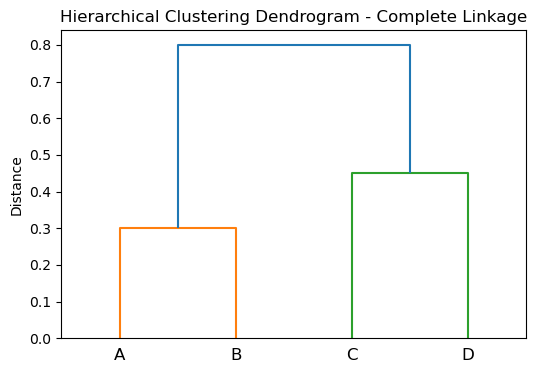

In [200]:
condensed_data = squareform(data)

Z = linkage(condensed_data, method='complete')
plt.figure(figsize=(6, 4))
dendrogram(Z, labels=['A', 'B', 'C', 'D'])
plt.title('Hierarchical Clustering Dendrogram - Complete Linkage')
plt.ylabel('Distance')
plt.show()



(b)

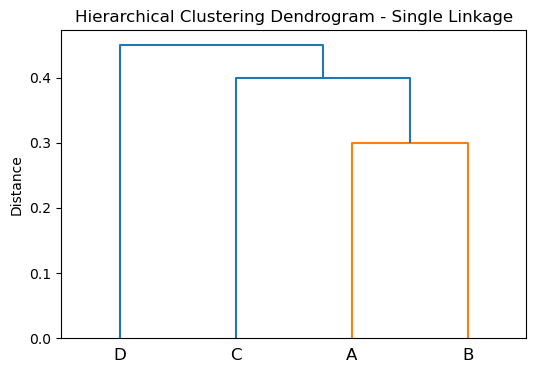

In [196]:
Z = linkage(condensed_data, method='single')
plt.figure(figsize=(6, 4))
dendrogram(Z, labels=['A', 'B', 'C', 'D'])
plt.title('Hierarchical Clustering Dendrogram - Single Linkage')
plt.ylabel('Distance')
plt.show()

(c)

Cluster 1: A and B

Cluster 2: C and D

(d)

Cluster 1 : A and B and C

Cluster 2: D

(e)

at 0.3, A and B merge

at 0.45, c and d merge

at 0.8, (A and B) and (C and D) merge